# ElectricityLoadDiagrams20112014

**Associated Tasks:** Regression, Clustering

#### Information About Dataset

* Data set has *no missing* values.
* Values are in kW of each 15 min. To convert values in kWh values must be divided by 4.
* Each column represent one client. Some clients were created after 2011. In these cases consumption were considered zero.
* All time labels report to Portuguese hour. However all days present 96 measures (24*4). Every year in March time change day (which has only 23 hours) the values between 1:00 am and 2:00 am are zero for all points. Every year in October time change day (which has 25 hours) the values between 1:00 am and 2:00 am aggregate the consumption of two hours.

#### Variable Information

* Data set were saved as txt using csv format, using semi colon (;).
First column present date and time as a string with the following format **'yyyy-mm-dd hh:mm:ss'**
* Other columns present float values with consumption in kW

In [1]:
# import required modules

import pandas as pd
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# read the dataset
with zipfile.ZipFile(r'D:\Codes\Artificial_Intelligence\Machine_Learning\Machine-Learning-With-Scikit-Learn\Projects\Datasets\electricityload.zip') as z:
     with z.open('LD2011_2014.txt', 'r') as f:
         
         print('Reading the dataset......')
         df = pd.read_csv(f,
                          sep=';',
                          low_memory=False,
                          parse_dates=[0],
                          decimal=',')
         print('Reading dataset successful')
         
print(f'\nSize of original dataset: {df.shape}')

Reading the dataset......
Reading dataset successful

Size of original dataset: (140256, 371)


In [3]:
df.head()

,Unnamed: 0,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
0,2011-01-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2011-01-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2011-01-01 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2011-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2011-01-01 01:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.tail()

,Unnamed: 0,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
140251,2014-12-31 23:00:00,2.538071,22.048364,1.737619,150.406504,85.365854,303.571429,11.305822,282.828283,68.181818,...,276.945039,28200.0,1616.033755,1363.636364,29.986962,5.851375,697.102722,176.961603,651.026393,7621.621622
140252,2014-12-31 23:15:00,2.538071,21.337127,1.737619,166.666667,81.707317,324.404762,11.305822,252.525253,64.685315,...,279.800143,28300.0,1569.620253,1340.909091,29.986962,9.947338,671.641791,168.614357,669.354839,6702.702703
140253,2014-12-31 23:30:00,2.538071,20.625889,1.737619,162.601626,82.926829,318.452381,10.175240,242.424242,61.188811,...,284.796574,27800.0,1556.962025,1318.181818,27.379400,9.362200,670.763828,153.589316,670.087977,6864.864865
140254,2014-12-31 23:45:00,1.269036,21.337127,1.737619,166.666667,85.365854,285.714286,10.175240,225.589226,64.685315,...,246.252677,28000.0,1443.037975,909.090909,26.075619,4.095963,664.618086,146.911519,646.627566,6540.540541
140255,2015-01-01 00:00:00,2.538071,19.914651,1.737619,178.861789,84.146341,279.761905,10.175240,249.158249,62.937063,...,188.436831,27800.0,1409.282700,954.545455,27.379400,4.095963,628.621598,131.886477,673.020528,7135.135135


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Columns: 371 entries, Unnamed: 0 to MT_370
dtypes: datetime64[ns](1), float64(370)
memory usage: 397.0 MB


In [6]:
df.describe()

,Unnamed: 0,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
count,140256,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,...,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000,140256.000000
mean,2012-12-31 12:07:29.999999488,3.970785,20.768480,2.918308,82.184490,37.240309,141.227385,4.521338,191.401476,39.975354,...,218.213701,37607.987537,1887.427366,2940.031734,65.413150,9.269709,424.262904,94.704717,625.251734,8722.355145
min,2011-01-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2012-01-01 06:11:15,0.000000,2.844950,0.000000,36.585366,15.853659,71.428571,0.565291,111.111111,13.986014,...,5.710207,0.000000,0.000000,0.000000,13.037810,0.000000,0.000000,30.050083,83.944282,0.000000
50%,2012-12-31 12:07:30,1.269036,24.893314,1.737619,87.398374,39.024390,157.738095,2.826456,222.222222,40.209790,...,131.334761,24100.000000,1050.632911,2136.363636,31.290743,7.021650,525.899912,76.794658,758.064516,0.000000
75%,2013-12-31 18:03:45,2.538071,29.871977,1.737619,115.853659,54.878049,205.357143,4.522329,279.461279,57.692308,...,403.283369,54800.000000,3312.236287,5363.636364,108.213820,11.702750,627.743635,151.919866,875.366569,17783.783784
max,2015-01-01 00:00:00,48.223350,115.220484,151.172893,321.138211,150.000000,535.714286,44.657999,552.188552,157.342657,...,852.962170,192800.000000,7751.054852,12386.363636,335.071708,60.269163,1138.718174,362.270451,1549.120235,30918.918919
std,NaN,5.983965,13.272415,11.014456,58.248392,26.461327,98.439984,6.485684,121.981187,29.814595,...,204.833532,38691.954832,1801.486488,2732.251967,65.007818,10.016782,274.337122,80.297301,380.656042,9195.155777


In [7]:
df.select_dtypes(include='number').columns

Index(['MT_001', 'MT_002', 'MT_003', 'MT_004', 'MT_005', 'MT_006', 'MT_007',
       'MT_008', 'MT_009', 'MT_010',
       ...
       'MT_361', 'MT_362', 'MT_363', 'MT_364', 'MT_365', 'MT_366', 'MT_367',
       'MT_368', 'MT_369', 'MT_370'],
      dtype='object', length=370)

In [8]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [9]:
cols = df.columns.tolist()[1:]

In [10]:
max_date = df[(df.iloc[:, 1:].astype(int) == 0).all(axis=1)]['Unnamed: 0'].max()
max_date

NaT

In [11]:
(df[cols].astype(int)).iloc[0:50].max().tolist()

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 100,
 0,
 0,
 0,
 0,
 0,
 0,
 302,
 52,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 68,
 0,
 42,
 22,
 0,
 2064,
 196,
 2264,
 0,
 0,
 1014,
 0,
 156,
 29,
 0,
 222,
 155,
 0,
 86,
 157,
 82,
 0,
 0,
 0,
 101,
 0,
 47,
 59,
 0,
 0,
 0,
 13,
 24,
 212,
 327,
 1000,
 285,
 284,
 2245,
 287,
 13291,
 94,
 179,
 311,
 428,
 203,
 239,
 321,
 485,
 375,
 124,
 376,
 4336,
 442,
 490,
 90,
 238,
 678,
 232,
 207,
 1438,
 132,
 782,
 382,
 1594,
 109,
 718,
 54

In [12]:
sample_size = pd.to_datetime('2013-06-30 23:00:00')
sample_size

Timestamp('2013-06-30 23:00:00')

In [13]:
# the dataset is too large for my pc so I am cr
sdf = df[df['Unnamed: 0'] <= sample_size].copy()
print(f'Shape of sample dataset: {sdf.shape}')

Shape of sample dataset: (87548, 371)


In [14]:
sdf.tail()

,Unnamed: 0,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
87543,2013-06-30 22:00:00,1.269036,41.251778,1.737619,148.373984,59.756098,252.976190,5.087620,313.131313,54.195804,...,242.683797,103800.0,3995.780591,8863.636364,198.174707,20.479813,539.947322,170.283806,892.961877,19978.378378
87544,2013-06-30 22:15:00,2.538071,41.963016,1.737619,142.276423,64.634146,244.047619,7.348785,303.030303,54.195804,...,204.139900,103800.0,3907.172996,7863.636364,168.187744,27.501463,617.208077,151.919866,895.161290,21405.405405
87545,2013-06-30 22:30:00,2.538071,40.540541,1.737619,150.406504,60.975610,235.119048,5.652911,299.663300,52.447552,...,165.596003,104100.0,2957.805907,8000.000000,164.276402,23.405500,699.736611,150.250417,901.759531,19978.378378
87546,2013-06-30 22:45:00,2.538071,41.251778,1.737619,154.471545,57.317073,241.071429,5.087620,316.498316,48.951049,...,159.885796,99100.0,2392.405063,3204.545455,164.276402,35.108250,661.984197,135.225376,859.970674,19740.540541
87547,2013-06-30 23:00:00,5.076142,39.829303,1.737619,138.211382,58.536585,235.119048,3.957038,306.397306,45.454545,...,137.758744,71000.0,2282.700422,3000.000000,159.061278,19.309538,639.157155,140.233723,879.032258,19264.864865


In [15]:
sdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 87548 entries, 0 to 87547
Columns: 371 entries, Unnamed: 0 to MT_370
dtypes: datetime64[ns](1), float64(370)
memory usage: 248.5 MB


In [16]:
sdf.describe()

,Unnamed: 0,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
count,87548,87548.000000,87548.000000,87548.000000,87548.000000,87548.000000,87548.000000,87548.000000,87548.000000,87548.000000,...,87548.000000,87548.000000,87548.000000,87548.000000,87548.000000,87548.000000,87548.000000,87548.000000,87548.000000,87548.000000
mean,2012-03-31 23:37:29.999999744,2.867897,16.370625,3.637662,60.523500,28.316021,113.016336,2.680716,152.215143,32.427126,...,169.781581,29017.118609,1532.627020,2385.506444,54.620810,7.196768,346.084524,74.718735,504.573620,3291.921899
min,2011-01-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2011-08-16 23:56:15,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2012-03-31 23:37:30,1.269036,22.048364,1.737619,69.105691,31.707317,125.000000,2.261164,191.919192,34.965035,...,84.939329,15800.000000,869.198312,1568.181818,18.252934,4.681100,467.954346,50.083472,710.410557,0.000000
75%,2012-11-14 23:18:45,2.538071,28.449502,2.606429,95.528455,47.560976,193.452381,3.391747,265.993266,52.447552,...,366.345468,46800.000000,2940.928270,3931.818182,106.910039,9.362200,602.282704,135.225376,858.504399,0.000000
max,2013-06-30 23:00:00,48.223350,115.220484,151.172893,308.943089,120.731707,535.714286,35.613341,535.353535,157.342657,...,849.393291,192800.000000,7350.210970,10000.000000,335.071708,57.343476,1130.816506,360.601002,1395.894428,29254.054054
std,NaN,5.135821,14.408652,13.889186,57.602641,26.509814,104.716741,4.369081,133.003431,32.333019,...,197.515581,36276.930256,1806.925821,2709.482548,68.636134,9.701026,296.044536,79.530374,425.465848,6920.084237


# Visualizing the Data

In [17]:
sdf[cols].mean()

MT_001       2.867897
MT_002      16.370625
MT_003       3.637662
MT_004      60.523500
MT_005      28.316021
             ...     
MT_366       7.196768
MT_367     346.084524
MT_368      74.718735
MT_369     504.573620
MT_370    3291.921899
Length: 370, dtype: float64

In [18]:
mean_value = sdf[cols].mean()
std_value = sdf[cols].std()
min_value = sdf[cols].min()
max_value = sdf[cols].max()

analytic_df = pd.DataFrame({
    #'columns': mean_value.index,
    'Mean' : mean_value,
    'Standard_Deviation': std_value,
    'Minimun Value': min_value,
    'Maximum Value': max_value
})
analytic_df

,Mean,Standard_Deviation,Minimun Value,Maximum Value
MT_001,2.867897,5.135821,0.0,48.223350
MT_002,16.370625,14.408652,0.0,115.220484
MT_003,3.637662,13.889186,0.0,151.172893
MT_004,60.523500,57.602641,0.0,308.943089
MT_005,28.316021,26.509814,0.0,120.731707
...,...,...,...,...
MT_366,7.196768,9.701026,0.0,57.343476
MT_367,346.084524,296.044536,0.0,1130.816506
MT_368,74.718735,79.530374,0.0,360.601002
MT_369,504.573620,425.465848,0.0,1395.894428


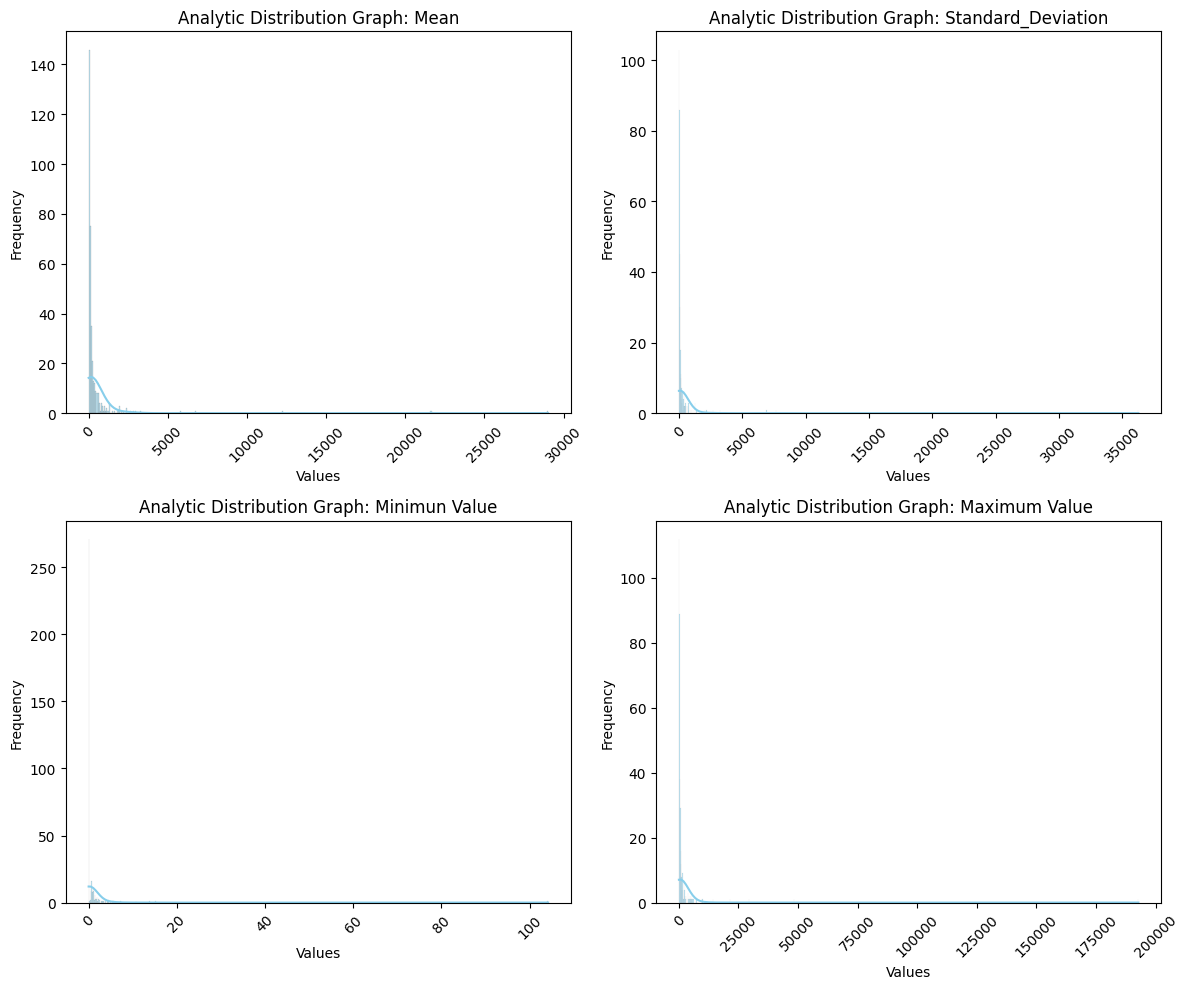

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
 
for i, col in enumerate(analytic_df.columns):
    sns.histplot(analytic_df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Analytic Distribution Graph: {col}')
    axes[i].set_xlabel('Values')
    axes[i].set_ylabel('Frequency')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


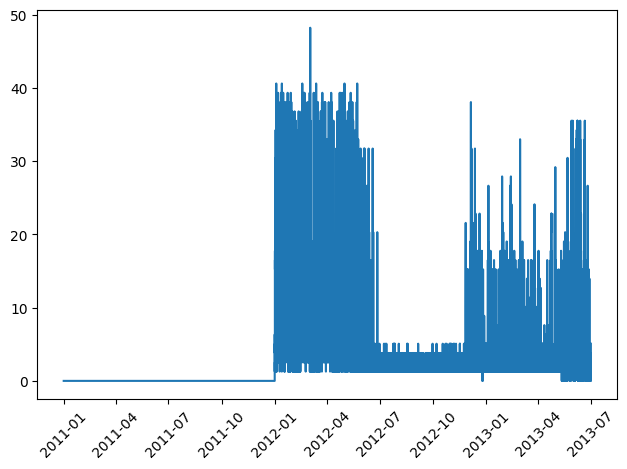

In [31]:
plt.Figure(figsize=(45, 10))
plt.plot(sdf['Unnamed: 0'], sdf['MT_001'])
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

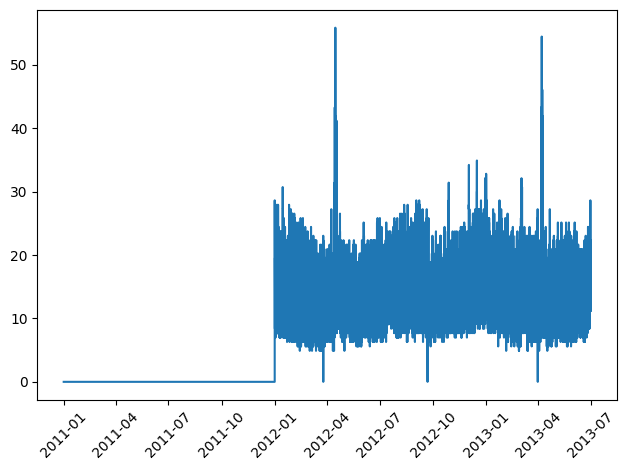

In [32]:
plt.Figure(figsize=(45, 10))
plt.plot(sdf['Unnamed: 0'], sdf['MT_034'])
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

According to the above graph it seems like values till 2012-01 are all 0 so lets confirm it

Text(0, 0.5, 'Max Values of each column')

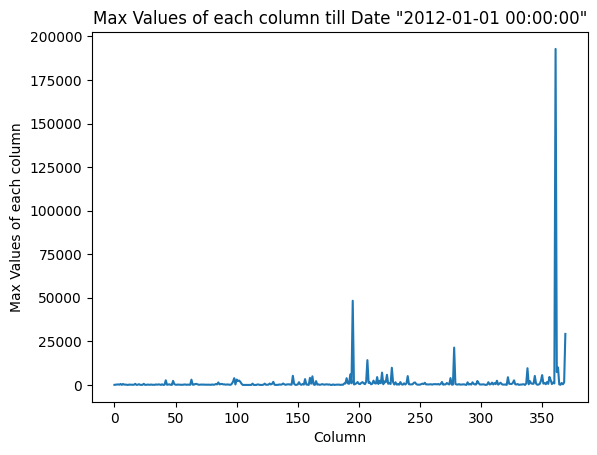

In [61]:
max_values = sdf[sdf['Unnamed: 0'] < pd.to_datetime("2012-01-01 00:00:00")].max()[1:].tolist()

plt.plot([i for i in range(len(max_value))], max_value)
plt.title('Max Values of each column till Date "2012-01-01 00:00:00"')
plt.xlabel('Column')
plt.ylabel('Max Values of each column')

Using this we can say there are some value despite most of the columns have max value 0

lets plot a graph for maximum value of each row not each column

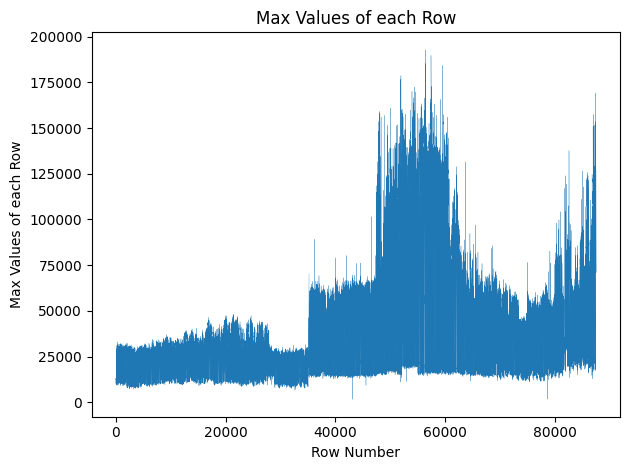

In [87]:
max_values = sdf.iloc[:, 1:].max(axis=1).tolist()

plt.Figure(figsize=(100, 10))
plt.plot([i for i in range(len(max_values))], max_values, linewidth=0.2)
plt.title('Max Values of each Row')
plt.xlabel('Row Number')
plt.ylabel('Max Values of each Row')
# plt.tick_params(axis=x, rotation=45)
plt.tight_layout()
plt.show()

This plot proves the that now all rows have 0 values

### Let's check for outliers

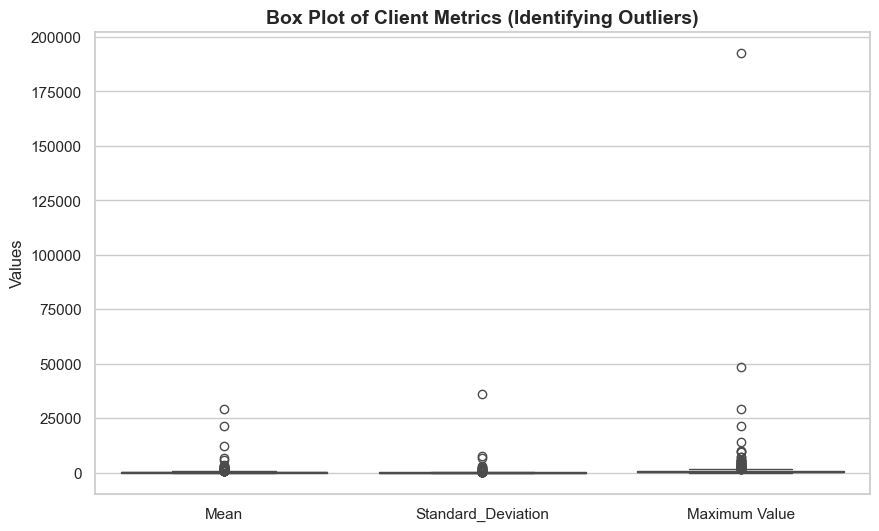

In [90]:
sns.set_theme(style="whitegrid")
# Create boxplots for Mean, Std, and Max values
plt.figure(figsize=(10, 6))
sns.boxplot(data=analytic_df[['Mean', 'Standard_Deviation', 'Maximum Value']])      #, palette="indigo"
plt.title("Box Plot of Client Metrics (Identifying Outliers)", fontsize=14, fontweight='bold')
plt.ylabel("Values")
plt.show()